# HyXBeachNH: A hybrid method for nearshore wave processes 
(scheme to addapt)

![sketch](assets/hyswash-sketch.png)

## 4. Reconstruction: Principal Component Analysis (PCA) & Radial Basis Fucntions (RBF)

The reconstruction of wave parameters is carried out by an interpolation technique based on radial basis functions (RBF), a scheme wich is very convenient for scatter and multivariate data. The RBF approximation has been applied successfully in many fields, usually with better results than other interpolation methods (Hardy, 1990).
    
Suppose that $f=f(x)$ is the real-valued function that we want to approximate. We are given M scattered data points $\{x_1,..., x_M\}$ of dimension $\textit{n}$ and the associated real function values $\{f_1, ..., f_M\}$, being $f_i = f(x_j), j = 1,...,M$. The RBF interpolation method consists of a weighted sum of radially symmetric basic functions located at the data points. The approximation function is assumed to be of the form:
$$RBF(x) = p(x) + \sum\limits_{j=1}^M a_j\Phi{\large (}{\large \parallel}{x - x_j}{\large \parallel}{\large )}$$

In [1]:
import os
import os.path as op

import numpy as np
import xarray as xr
from bluemath_tk.core.io import load_model
from bluemath_tk.datamining.pca import PCA
from bluemath_tk.interpolation.rbf import RBF
from matplotlib import pyplot as plt

# from utils.plotting import show_graph_for_different_parameters

root_dir = os.getcwd()
output_dir = op.join(root_dir, "output_Zarautz")
templates_dir = op.join(root_dir, "templates")
export_dir = op.join(root_dir, "exported_Zarautz")
os.makedirs(export_dir, exist_ok=True)

Load xbeach_model and mda from a pickle file and postprocessed_output NetCDF file (files generated in the previous 01_Zarautz_Wrapper.ipynb)

In [2]:
mda = load_model(op.join(export_dir, "mda_model.pkl"))
xbeach_model = load_model(op.join(export_dir, "xbeach_model.pkl"))
depth_file = op.join(templates_dir, "bed.dep")
depth_array = np.loadtxt(depth_file)[2, :] * -1
postprocessed_output = xr.open_dataset(op.join(output_dir, "output_postprocessed.nc"))

In [3]:
postprocessed_output

<xarray.Dataset> Size: 30MB
Dimensions:   (case_num: 10, Xp: 522, Tsec: 701)
Coordinates:
  * Xp        (Xp) float64 4kB 0.218 4.718 9.218 ... 1.238e+03 1.239e+03
  * case_num  (case_num) int64 80B 0 1 2 3 4 5 6 7 8 9
  * Tsec      (Tsec) float64 6kB 0.0 6.0 12.0 ... 4.188e+03 4.194e+03 4.2e+03
Data variables:
    Msetup    (case_num, Xp) float64 42kB ...
    Hrms      (case_num, Xp) float64 42kB ...
    Hs        (case_num, Xp) float64 42kB ...
    Hss       (case_num, Xp) float64 42kB ...
    ig        (case_num, Xp) float64 42kB ...
    Hvlf      (case_num, Xp) float64 42kB ...
    Watlev    (case_num, Tsec, Xp) float64 29MB ...

Apply PCA to the postprocessed output

In [4]:
# explained variance
variance = 0.998

pca = {}
for variable in ["Msetup", "Hrms", "ig"]:
    pca[variable] = PCA(n_components=variance)
    _pcs_ds = pca[variable].fit_transform(
        data=postprocessed_output,
        vars_to_stack=[variable],
        coords_to_stack=["Xp"],
        pca_dim_for_rows="case_num",
        value_to_replace_nans={"Msetup": 0.0, "Hrms": 0.0, "ig": 0.0},
    )
    pca[variable].save_model(model_path=op.join(export_dir, f"pca_{variable}.pkl"))

2025-08-25 10:23:27,176 - PCA - WARNING - Using 380 out of 522 available variables 
If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method


2025-08-25 10:23:27,278 - PCA - WARNING - Attribute pcs is an xarray Dataset / Dataarray and will be pickled!
2025-08-25 10:23:27,281 - PCA - WARNING - Using 225 out of 522 available variables 
If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method
2025-08-25 10:23:27,284 - PCA - WARNING - Attribute pcs is an xarray Dataset / Dataarray and will be pickled!
2025-08-25 10:23:27,287 - PCA - WARNING - Using 225 out of 522 available variables 
If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method
2025-08-25 10:23:27,289 - PCA - WARNING - Attribute pcs is an xarray Dataset / Dataarray and will be pickled!



        -------------------------------------------------------------------
        | Initializing PCA reduction model with the following parameters:
        |    - n_components: 0.998
        |    - is_incremental: False
        | For more information, please refer to the documentation.
        -------------------------------------------------------------------
        

        -------------------------------------------------------------------
        | Initializing PCA reduction model with the following parameters:
        |    - n_components: 0.998
        |    - is_incremental: False
        | For more information, please refer to the documentation.
        -------------------------------------------------------------------
        

        -------------------------------------------------------------------
        | Initializing PCA reduction model with the following parameters:
        |    - n_components: 0.998
        |    - is_incremental: False
        | For more informat

Apply RBF reconstruction

In [5]:
rbf = {}
for variable in ["Msetup", "Hrms", "ig"]:
    rbf[variable] = RBF()
    rbf[variable].fit(
        subset_data=mda.centroids.iloc[postprocessed_output["case_num"].values, :],
        target_data=pca[variable].pcs_df,
    )
    rbf[variable].save_model(
        model_path=op.join(export_dir, f"rbf_{variable}.pkl"),
    )


        ---------------------------------------------------------------------------------
        | Initializing RBF interpolation model with the following parameters:
        |    - sigma_min: 0.001
        |    - sigma_max: 0.1
        |    - sigma_diff: 0.0001
        |    - sigma_opt: None
        |    - kernel: gaussian
        |    - smooth: 1e-05
        | For more information, please refer to the documentation.
        | Recommended lecture: https://link.springer.com/article/10.1023/A:1018975909870
        ---------------------------------------------------------------------------------
        

        ---------------------------------------------------------------------------------
        | Initializing RBF interpolation model with the following parameters:
        |    - sigma_min: 0.001
        |    - sigma_max: 0.1
        |    - sigma_diff: 0.0001
        |    - sigma_opt: None
        |    - kernel: gaussian
        |    - smooth: 1e-05
        | For more information,

In [6]:
# The process PCA + RBF can take hours. To avoid run them again we can load the models from the exported folder
# pca_Hrms = load_model(op.join(export_dir, "pca_Hrms_model.pkl"))
# rbf_Hrms = load_model(op.join(export_dir, "rbf_model.pkl"))

Plot differences between numerical and analytical results (first 10 cases). Use df_cases to select different cases.

In [7]:
def rbf_pca_predict(df_dataset, pca, rbf):
    # Apply PCA to the dataset
    predicted_Setup_coef = rbf.predict(dataset=df_dataset)
    predicted_Setup_ds = xr.Dataset(
        {
            "PCs": (["case_num", "n_component"], predicted_Setup_coef.values),
        },
        coords={
            "case_num": np.arange(predicted_Setup_coef.values.shape[0]),
            "n_component": np.arange(predicted_Setup_coef.values.shape[1]),
        },
    )
    ds_output = pca.inverse_transform(PCs=predicted_Setup_ds)
    return ds_output

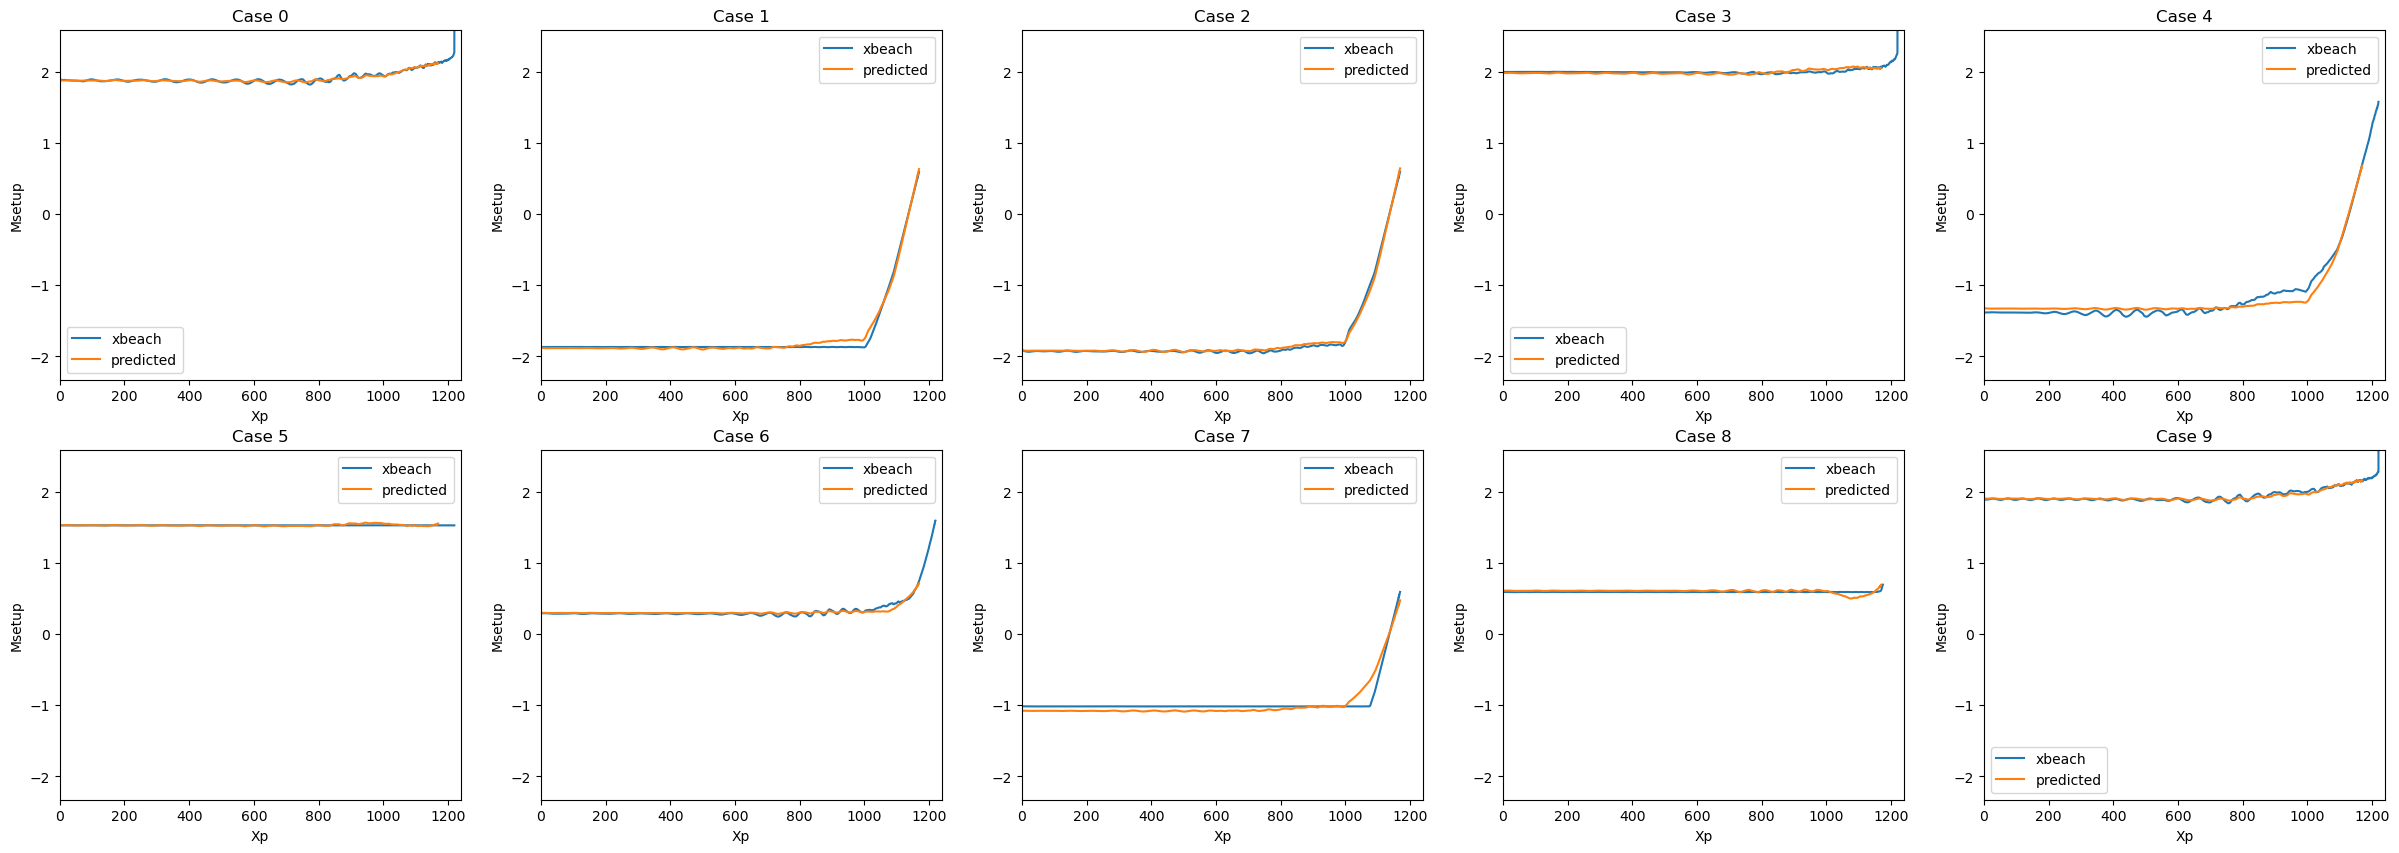

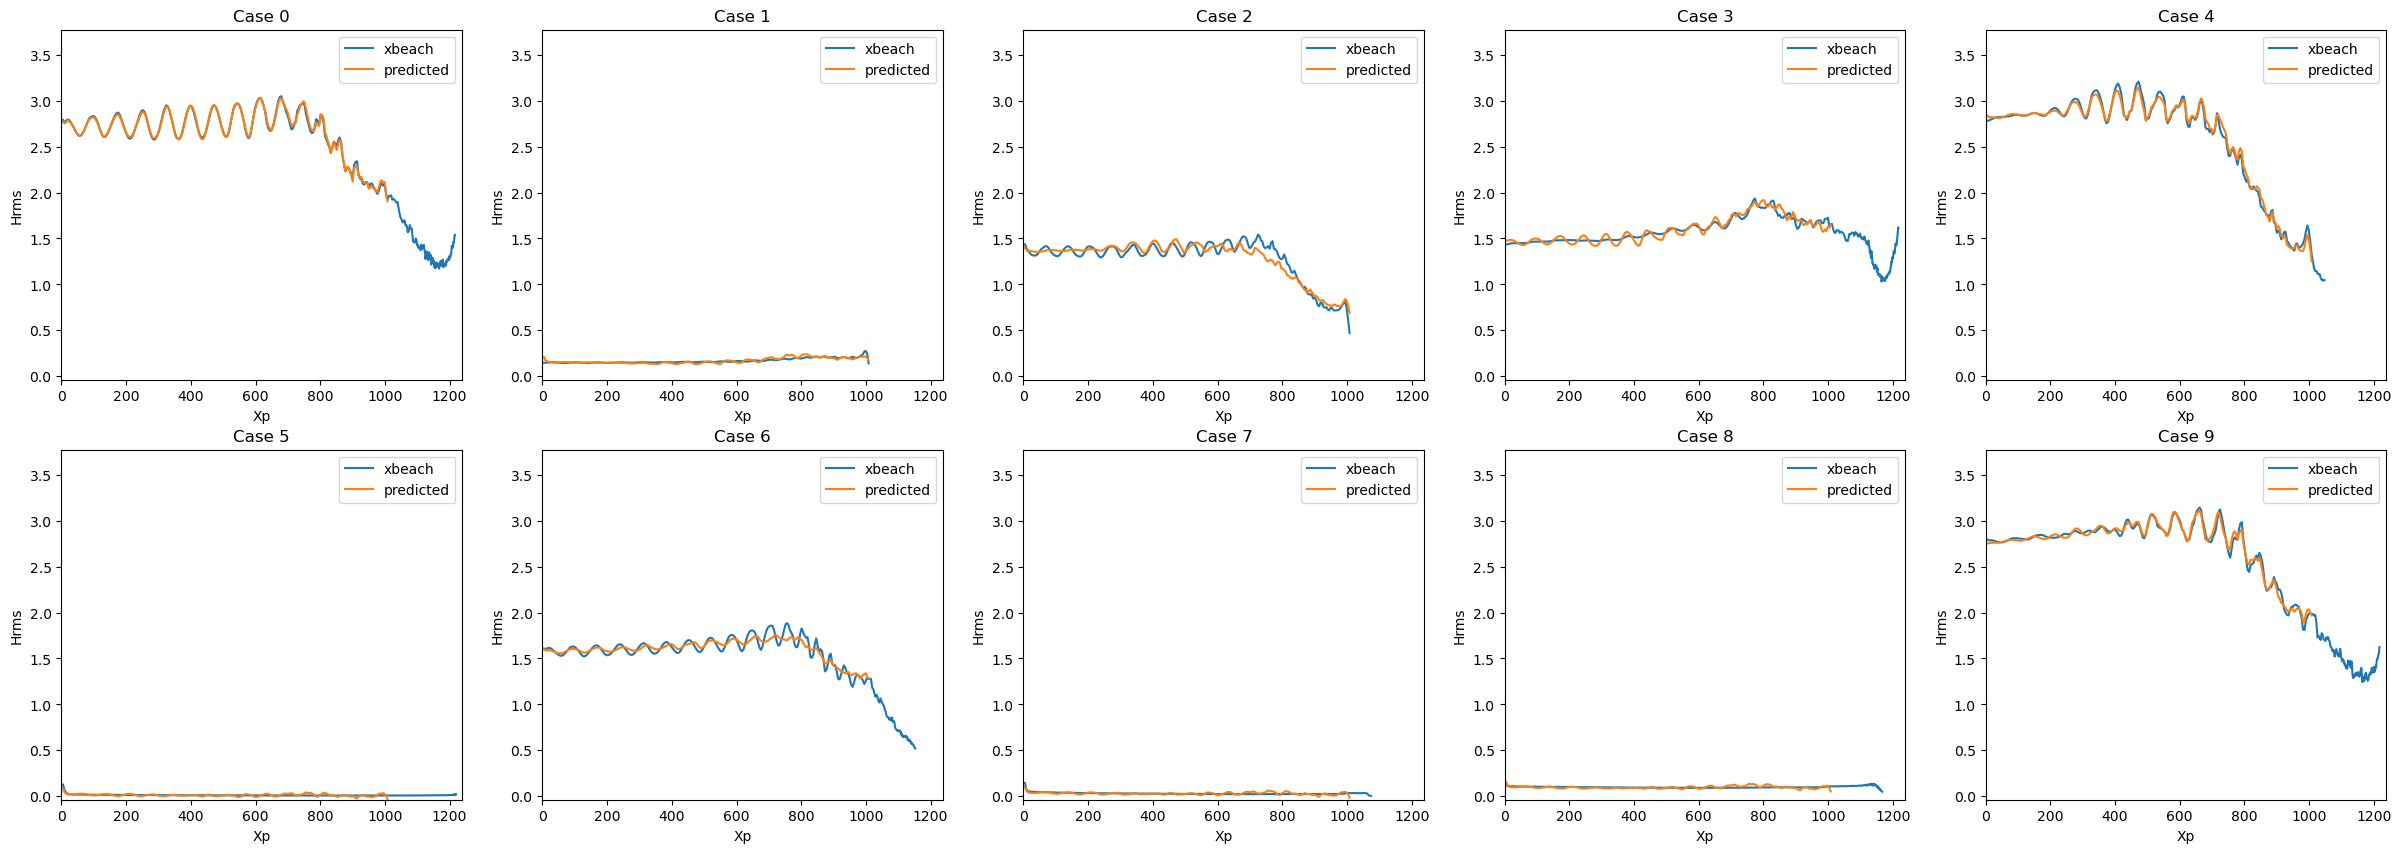

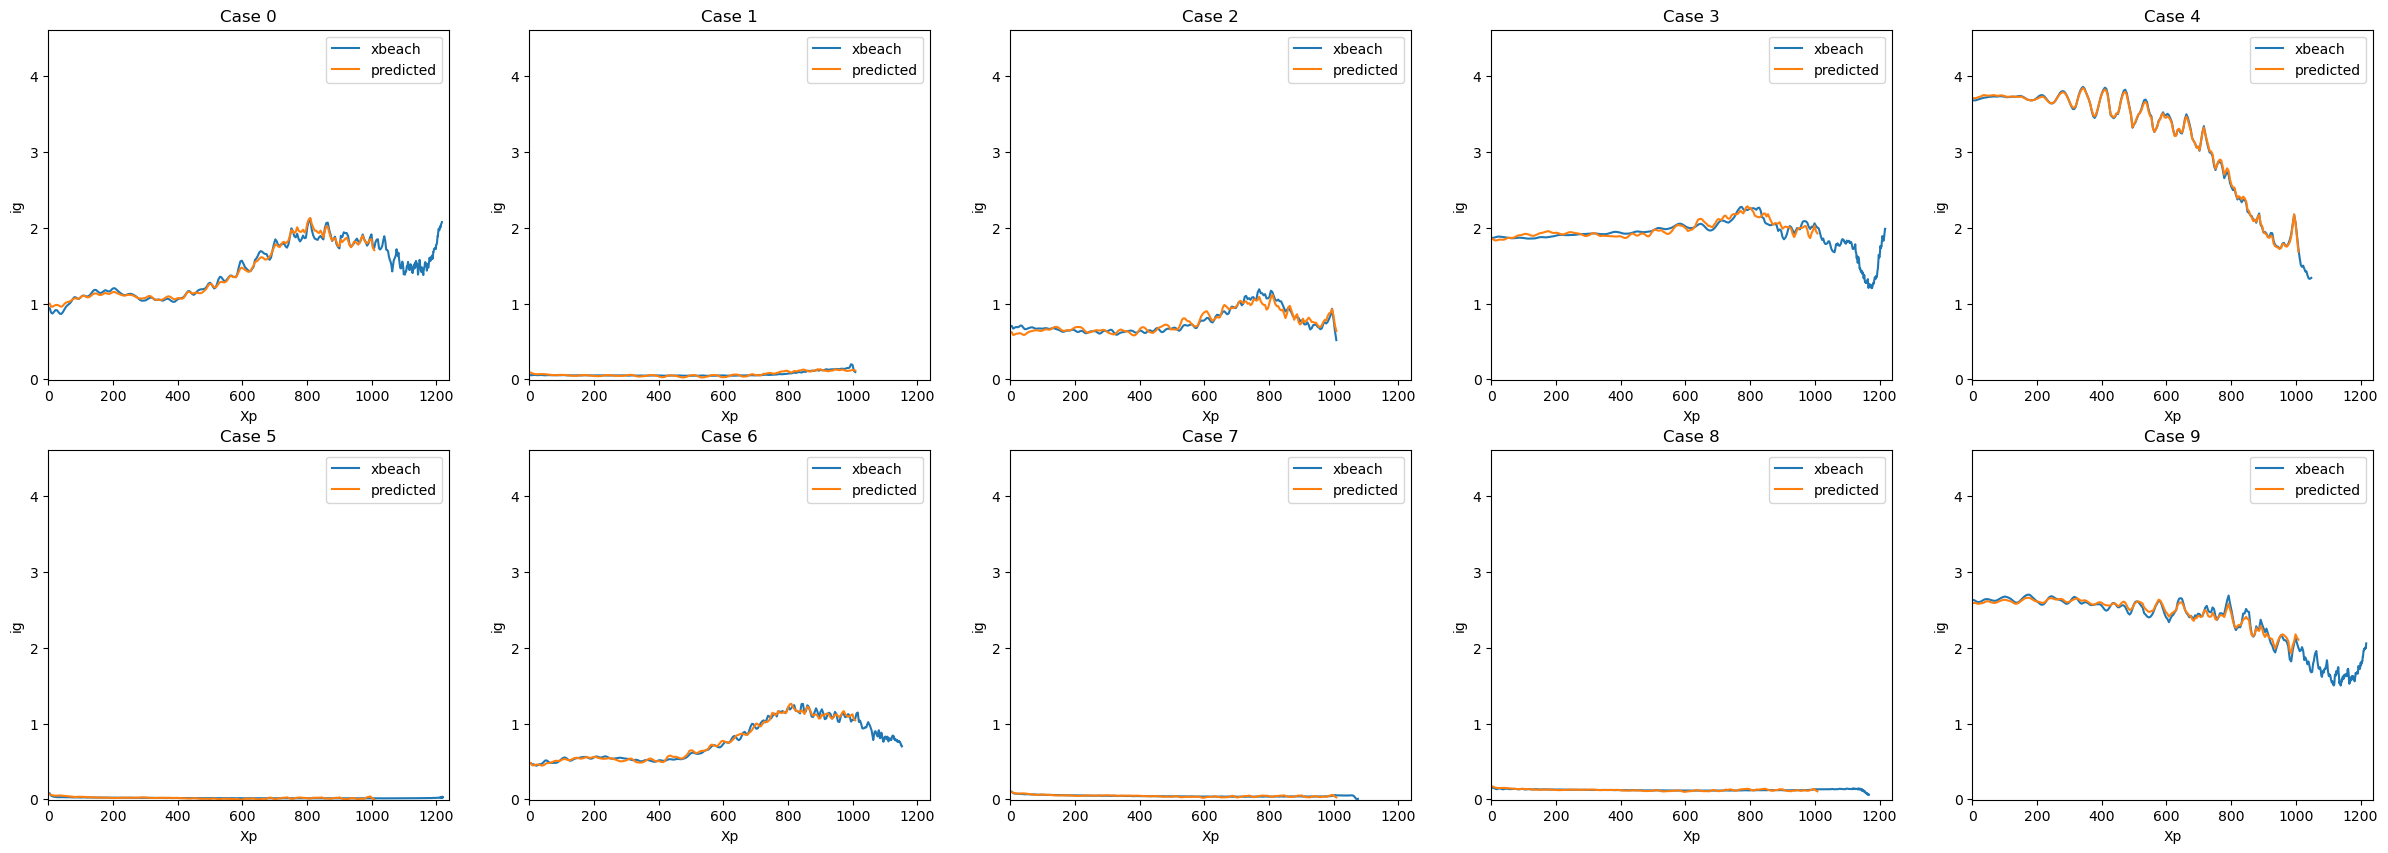

In [8]:
df_cases = mda.centroids[0:10]
xmax = postprocessed_output["Xp"].max().values
for variable in ["Msetup", "Hrms", "ig"]:
    ds_output = rbf_pca_predict(
        df_dataset=df_cases, pca=pca[variable], rbf=rbf[variable]
    )
    # if variable == "Msetup":
    #    WL_values_centroids = mda.centroids[0:10]["WL"].values
    #    ds_output["Msetup"] = ds_output["Msetup"] - xr.DataArray(WL_values_centroids, dims=["case_num"])
    #    postprocessed_output["Msetup"] = postprocessed_output["Msetup"] - xr.DataArray(WL_values_centroids, dims=["case_num"])
    fig, axes = plt.subplots(2, 5, figsize=(30, 10))
    ymax = np.nanmax(ds_output[variable].values) * 1.2
    ymin = np.nanmin(ds_output[variable].values) * 1.2
    for i in np.arange(0, 10):
        postprocessed_output.sel(case_num=i)[variable].plot(
            xlim=(0, xmax), ylim=(ymin, ymax), ax=axes[i // 5, i % 5], label="xbeach"
        )
        ds_output.sel(case_num=i)[variable].plot(
            xlim=(0, xmax), ax=axes[i // 5, i % 5], label="predicted"
        )
        axes[i // 5, i % 5].set_title(f"Case {i}")
        axes[i // 5, i % 5].legend()